# YipitData Signal Validation — YIPIT-SIGNAL-001
## § 1 — Data Ingestion and Sanity EDA

In [1]:
# T001 — imports only; every library here is offline (no HTTP, no API calls).
# requests / urllib / yfinance / fredapi are explicitly banned per methodology.md.
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# T001 — SHA-256 hash verification against data-contracts.md.
# We assert hashes to fail loud if data drifts or is accidentally mutated.
# If either assert fires, this is a STOP-WORK condition — escalate to Director.
EXPECTED_HASHES = {
    "data/retail_sales_fred.csv": "332d0d032b5eb1580d0e24fe3b9213749d2cdbc8f5d1b3b3c126d518a38c5aa1",
    "data/walmart_revenue.csv":   "c116c39388b35c482512649bb0a25bd451989d34343432219fb5c83e67979502",
}

def sha256_file(path: str) -> str:
    """Read a file in chunks and return its hex SHA-256 digest."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

for fpath, expected in EXPECTED_HASHES.items():
    actual = sha256_file(fpath)
    assert actual == expected, (
        f"HASH MISMATCH for {fpath}: got {actual}, expected {expected}"
    )
    print(f"✓ {fpath}: hash OK")

✓ data/retail_sales_fred.csv: hash OK
✓ data/walmart_revenue.csv: hash OK


In [4]:
# T001 — load both CSVs from data/ (the only permitted directory).
# Explicit pd.to_datetime() is used AFTER load — never parse_dates=True — so
# the raw column type is visible before parsing and we can assert the result.
# Neither dataframe is mutated in place here; all downstream transforms use copies.

fred_raw = pd.read_csv("data/retail_sales_fred.csv")
fred_raw["date"] = pd.to_datetime(fred_raw["date"])
# pandas >= 2.0 may return datetime64[us] or datetime64[ns] depending on version;
# is_datetime64_any_dtype() accepts all datetime64 variants — this is the correct check.
assert pd.api.types.is_datetime64_any_dtype(fred_raw["date"]), \
    "FRED date not parsed as datetime64"

wmt_raw = pd.read_csv("data/walmart_revenue.csv")
wmt_raw["date"] = pd.to_datetime(wmt_raw["date"])
assert pd.api.types.is_datetime64_any_dtype(wmt_raw["date"]), \
    "WMT date not parsed as datetime64"

print("CSVs loaded successfully.")

CSVs loaded successfully.


In [5]:
# T001 — sanity summary: row count, date range, NaN count, dtype for each series.
# Purpose: confirm every property claimed in data-contracts.md is present in memory.
# If any assertion here fires, halt and escalate — the data boundary is corrupted.

def series_summary(df: pd.DataFrame, name: str) -> None:
    """Print a tidy contract-verification table for a two-column (date, value) DataFrame."""
    nan_date  = int(df["date"].isna().sum())
    nan_value = int(df["value"].isna().sum())
    print(f"┌─ {name}")
    print(f"│  Rows        : {len(df):>6d}")
    print(f"│  Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"│  NaN (date)  : {nan_date}")
    print(f"│  NaN (value) : {nan_value}")
    print(f"│  dtype date  : {df['date'].dtype}")
    print(f"│  dtype value : {df['value'].dtype}")
    print(f"│  value min   : {df['value'].min():>20,.1f}")
    print(f"└  value max   : {df['value'].max():>20,.1f}")
    print()
    # Hard assertions against data-contracts.md — fail loud if violated
    assert nan_date  == 0, f"{name}: unexpected NaN in date column"
    assert nan_value == 0, f"{name}: unexpected NaN in value column"

series_summary(fred_raw, "FRED RSXFS (monthly)")
series_summary(wmt_raw,  "Walmart revenue (quarterly)")

┌─ FRED RSXFS (monthly)
│  Rows        :    195
│  Date range  : 2010-01-01 → 2026-03-01
│  NaN (date)  : 0
│  NaN (value) : 0
│  dtype date  : datetime64[us]
│  dtype value : float64
│  value min   :            302,310.0
└  value max   :            651,843.0

┌─ Walmart revenue (quarterly)
│  Rows        :     65
│  Date range  : 2010-01-31 → 2026-01-31
│  NaN (date)  : 0
│  NaN (value) : 0
│  dtype date  : datetime64[us]
│  dtype value : float64
│  value min   :     99,811,000,000.0
└  value max   :    185,534,000,000.0



In [6]:
# T001 — compute YoY growth for the sanity overlay plot ONLY.
#
# ── FRED ─────────────────────────────────────────────────────────────────────
# We aggregate monthly observations to *calendar* quarters here because we only
# need rough visual alignment with the Walmart curve.
# WARNING: this calendar-quarter aggregation is NEVER used in any model.
# T003 will aggregate FRED on Walmart *fiscal*-quarter boundaries, which differ
# by one month — a mistake that has tripped previous candidates (methodology.md § 2).
# "QE" = quarter-end frequency (Mar 31, Jun 30, Sep 30, Dec 31) in pandas ≥ 2.2.
# We sum within each quarter because the FRED RSXFS values are dollar-denominated
# monthly totals; summing three months gives a correct quarterly aggregate.
# A new variable (fred_cq) is created so fred_raw is never mutated.
fred_cq = (
    fred_raw
    .set_index("date")["value"]
    .resample("QE")          # calendar quarter end
    .sum()
    .reset_index()
)
fred_cq.columns = ["date", "value"]

# YoY growth: same quarter one year ago = 4 quarters back.
# Result is a fraction (0.05 = 5 %).
fred_cq_yoy = fred_cq.copy()
fred_cq_yoy["yoy"] = fred_cq_yoy["value"] / fred_cq_yoy["value"].shift(4) - 1
fred_cq_yoy = fred_cq_yoy.dropna(subset=["yoy"]).reset_index(drop=True)

# ── Walmart ───────────────────────────────────────────────────────────────────
# Fiscal-quarter series; shift(4) gives the same fiscal quarter last year.
# Do NOT mutate wmt_raw; build a new dataframe.
wmt_yoy = wmt_raw.copy()
wmt_yoy["yoy"] = wmt_yoy["value"] / wmt_yoy["value"].shift(4) - 1
wmt_yoy = wmt_yoy.dropna(subset=["yoy"]).reset_index(drop=True)

print(
    f"FRED calendar-quarter YoY  : {len(fred_cq_yoy)} obs, "
    f"{fred_cq_yoy['date'].min().date()} → {fred_cq_yoy['date'].max().date()}"
)
print(
    f"Walmart fiscal-quarter YoY : {len(wmt_yoy)} obs, "
    f"{wmt_yoy['date'].min().date()} → {wmt_yoy['date'].max().date()}"
)
print()
print(
    "NOTE: FRED calendar-quarter aggregation above is for visualization only.\n"
    "      T003 applies Walmart-fiscal-quarter alignment for all modelling."
)

FRED calendar-quarter YoY  : 61 obs, 2011-03-31 → 2026-03-31
Walmart fiscal-quarter YoY : 61 obs, 2011-01-31 → 2026-01-31

NOTE: FRED calendar-quarter aggregation above is for visualization only.
      T003 applies Walmart-fiscal-quarter alignment for all modelling.


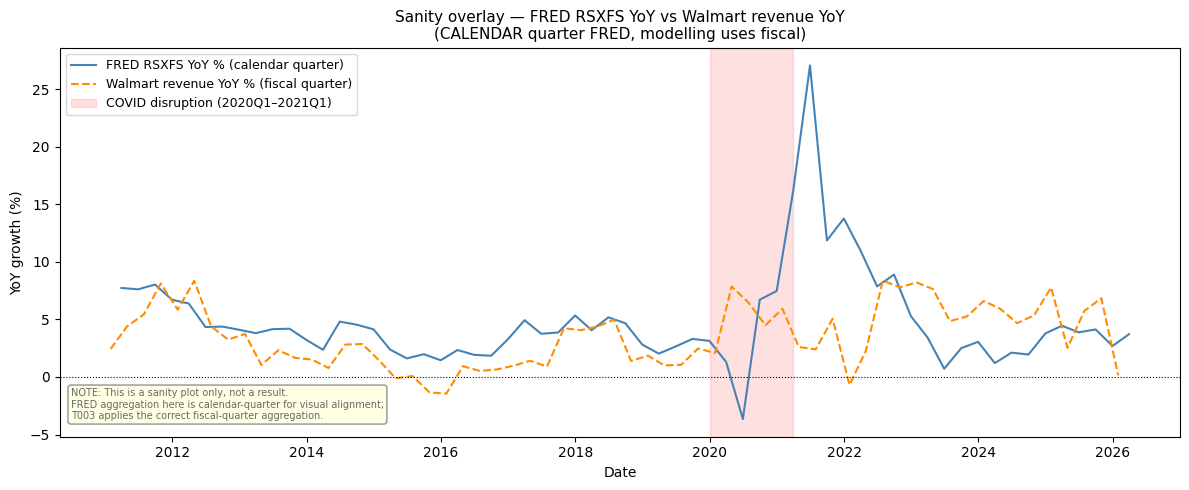

In [7]:
# T001 — sanity overlay plot: FRED RSXFS YoY vs Walmart revenue YoY.
# Purpose: confirm the two series move together directionally and that COVID-2020
# is visible as a shared outlier — which validates the signal merits further study
# AND flags the regime-treatment requirement (methodology.md § 8).
# matplotlib only; no seaborn, no plotly.

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    fred_cq_yoy["date"],
    fred_cq_yoy["yoy"] * 100,
    label="FRED RSXFS YoY % (calendar quarter)",
    color="steelblue",
    linewidth=1.5,
)
ax.plot(
    wmt_yoy["date"],
    wmt_yoy["yoy"] * 100,
    label="Walmart revenue YoY % (fiscal quarter)",
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
)

# Zero line for reference — makes direction-of-change obvious
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

# Shade the acute COVID disruption window (2020 Q1 – 2021 Q1) so the regime is
# impossible to miss visually; methodology.md § 8 requires this shading in results too.
ax.axvspan(
    pd.Timestamp("2020-01-01"), pd.Timestamp("2021-04-01"),
    alpha=0.12, color="red", label="COVID disruption (2020Q1–2021Q1)",
)

ax.set_title(
    "Sanity overlay — FRED RSXFS YoY vs Walmart revenue YoY\n"
    "(CALENDAR quarter FRED, modelling uses fiscal)",
    fontsize=11,
)
ax.set_ylabel("YoY growth (%)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9)

# Reviewer-facing caveat embedded in the figure so it survives export
ax.annotate(
    "NOTE: This is a sanity plot only, not a result.\n"
    "FRED aggregation here is calendar-quarter for visual alignment;\n"
    "T003 applies the correct fiscal-quarter aggregation.",
    xy=(0.01, 0.04),
    xycoords="axes fraction",
    fontsize=7,
    color="dimgray",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.85),
)

plt.tight_layout()
plt.show()

## → Next: T002 — Seasonal Naive Baseline

The baseline is built before any FRED-augmented model (non-negotiable ordering per methodology.md § 4).